In [26]:
import pandas as pd
df = pd.read_excel(r"C:\Users\hppat\OneDrive\Desktop\Untangle_zeroClutter\model\bank.xlsx")

In [27]:
df.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,.
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,.
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,.
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,.
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,.


In [28]:
df.columns

Index(['Account No', 'DATE', 'TRANSACTION DETAILS', 'CHQ.NO.', 'VALUE DATE',
       'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.'],
      dtype='object')

In [29]:
df.shape

(116201, 9)

In [30]:
df.groupby(['Account No']).agg('count')

,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,.
Account No,,,,,,,,
1196428',48779,48779,323,48779,16687,32092,48779,48779
1196711',10536,10521,561,10536,5025,5511,10536,10536
409000362497',29840,27356,0,29840,15477,14363,29840,29840
409000405747',51,51,0,51,28,23,51,51
409000425051',802,802,9,802,28,774,802,802
409000438611',4588,4588,4,4588,1333,3255,4588,4588
409000438620',13454,13454,8,13454,8391,5063,13454,13454
409000493201',1044,1044,0,1044,575,469,1044,1044
409000493210',6014,6014,0,6014,5227,787,6014,6014


In [31]:
df1 = df.drop(['.'], axis="columns")
df1.head()

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0


In [32]:
df1['DATE'] = pd.to_datetime(df1['DATE'])

In [33]:
df1.isnull().sum()

Account No                  0
DATE                        0
TRANSACTION DETAILS      2499
CHQ.NO.                115296
VALUE DATE                  0
WITHDRAWAL AMT          62652
DEPOSIT AMT             53549
BALANCE AMT                 0
dtype: int64

In [34]:
df1.dropna(subset=['TRANSACTION DETAILS'], inplace=True)

In [35]:
df1.isnull().sum()

Account No                  0
DATE                        0
TRANSACTION DETAILS         0
CHQ.NO.                112797
VALUE DATE                  0
WITHDRAWAL AMT          60153
DEPOSIT AMT             53549
BALANCE AMT                 0
dtype: int64

In [36]:
df1["WITHDRAWAL AMT"].fillna(0, inplace=True)

C:\Users\hppat\AppData\Local\Temp\ipykernel_23596\474798480.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1["WITHDRAWAL AMT"].fillna(0, inplace=True)


In [37]:
df1["DEPOSIT AMT"].fillna(0, inplace=True)

C:\Users\hppat\AppData\Local\Temp\ipykernel_23596\999116991.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1["DEPOSIT AMT"].fillna(0, inplace=True)


In [38]:
df1["CHQ.NO."].fillna("unknown", inplace=True)

C:\Users\hppat\AppData\Local\Temp\ipykernel_23596\2964009970.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1["CHQ.NO."].fillna("unknown", inplace=True)
C:\Users\hppat\AppData\Local\Temp\ipykernel_23596\2964009970.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df1["CHQ.NO."].fillna("unknown", inplace=True)


In [39]:
df1 = df1[df1['BALANCE AMT'] > -1000000]

In [40]:
df1.describe()

,DATE,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT
count,2925,2925,2.925000e+03,2.925000e+03,2.925000e+03
mean,2017-11-23 05:30:20.307692288,2017-11-23 05:30:20.307692288,8.392391e+04,8.920911e+04,1.204283e+06
min,2016-02-23 00:00:00,2016-02-23 00:00:00,0.000000e+00,0.000000e+00,1.383550e+05
25%,2016-12-08 00:00:00,2016-12-08 00:00:00,0.000000e+00,0.000000e+00,8.211816e+05
50%,2017-12-27 00:00:00,2017-12-27 00:00:00,0.000000e+00,1.000000e+03,1.087909e+06
75%,2018-08-24 00:00:00,2018-08-24 00:00:00,1.000000e+05,5.000000e+04,1.383087e+06
max,2019-03-05 00:00:00,2019-03-05 00:00:00,2.500000e+06,1.500000e+07,8.500000e+06
std,NaN,NaN,1.814605e+05,3.258025e+05,7.820032e+05


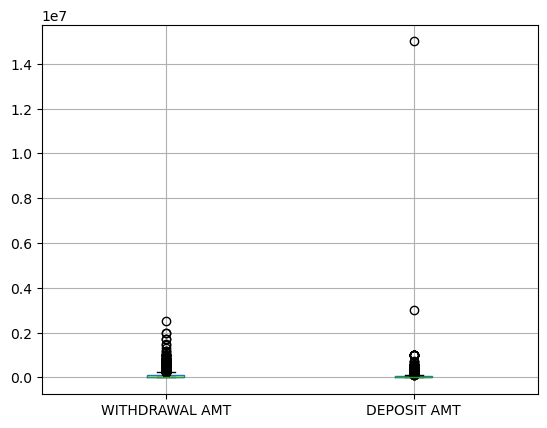

In [41]:
import matplotlib.pyplot as plt

df1[['WITHDRAWAL AMT','DEPOSIT AMT']].boxplot()
plt.show()

In [42]:
Q1 = df1['WITHDRAWAL AMT'].quantile(0.25)
Q3 = df1['WITHDRAWAL AMT'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df1[(df1['WITHDRAWAL AMT'] < lower) | (df1['WITHDRAWAL AMT'] > upper)]

In [43]:
df1.shape

(2925, 8)

In [44]:
df1['TRANSACTION DETAILS'].unique()

array(['TRF FROM  Indiaforensic SERVICES', 'FDRL/INTERNAL FUND TRANSFE',
       'TRF FRM  Indiaforensic SERVICES', ...,
       'TRF TO  Indiaforensic ONLINE SER', 720717634445,
       'IMPS 809712134438 FROM OX'], dtype=object)

In [45]:
df1['TRANSACTION DETAILS'].nunique()

2039

In [81]:
import numpy as np

# Clean Description instantly
df1["clean_desc"] = df1["TRANSACTION DETAILS"].astype(str).str.lower()
df1["clean_desc"] = df1["clean_desc"].str.replace(r'\d+', '', regex=True)
df1["clean_desc"] = df1["clean_desc"].str.replace(r'[/,:*.-]', ' ', regex=True)
df1["clean_desc"] = df1["clean_desc"].str.replace(r'\s+', ' ', regex=True).str.strip()

# Detect Type instantly
desc = df1["TRANSACTION DETAILS"].astype(str).str.lower()
conditions = [
    desc.str.contains("trf from", na=False),
    desc.str.contains("trf to|sweep", regex=True, na=False),
    desc.str.contains("neft|imps|upi", regex=True, na=False)
]
choices = ["income", "transfer", "bank_transfer"]
df1["type"] = np.select(conditions, choices, default="expense")

In [48]:
df1["clean_desc"] = df1["clean_desc"].fillna("unknown").astype(str).apply(remove_stopwords)

NameError: name 'remove_stopwords' is not defined

In [49]:
def extract_merchant(text):
    words = text.split()
    
    if len(words) == 0:
        return "unknown"
    
    return " ".join(words[:2])  # first 2 words

df1["merchant"] = df1["clean_desc"].apply(extract_merchant)

In [50]:
def fix_special_cases(row):
    text = str(row["TRANSACTION DETAILS"]).lower()
    
    if "sweep" in text:
        return "self transfer"
    elif "imps" in text and len(row["merchant"]) < 3:
        return "imps transfer"
    
    return row["merchant"]

df1["merchant"] = df1.apply(fix_special_cases, axis=1)

In [51]:
df1.head(20)

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,clean_desc,type,merchant
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,unknown,2017-06-29,0.0,1000000.0,1000000.0,trf from indiaforensic services,income,trf from
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,unknown,2017-07-05,0.0,1000000.0,2000000.0,trf from indiaforensic services,income,trf from
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,unknown,2017-07-18,0.0,500000.0,2500000.0,fdrl internal fund transfe,expense,fdrl internal
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,unknown,2017-08-01,0.0,3000000.0,5500000.0,trf frm indiaforensic services,expense,trf frm
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,6000000.0,fdrl internal fund transfe,expense,fdrl internal
5,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,6500000.0,fdrl internal fund transfe,expense,fdrl internal
6,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,7000000.0,fdrl internal fund transfe,expense,fdrl internal
7,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,7500000.0,fdrl internal fund transfe,expense,fdrl internal
8,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,8000000.0,fdrl internal fund transfe,expense,fdrl internal
9,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,8500000.0,fdrl internal fund transfe,expense,fdrl internal


In [52]:
df1["category"] = "others"

In [53]:
rules = {
    "food": ["swiggy", "zomato", "restaurant", "cafe"],
    "shopping": ["amazon", "flipkart", "myntra", "ajio"],
    "travel": ["uber", "ola", "irctc", "flight"],
    "bills": ["electricity", "water", "gas", "recharge"],
    "subscription": ["netflix", "spotify", "prime"],
    "salary": ["salary", "indiaforensic"],
}

In [54]:
def categorize(row):
    merchant = str(row["merchant"]).lower()
    t_type = row["type"]
    
    # Priority 1: Type-based
    if t_type == "income":
        return "income"
    elif t_type == "transfer":
        return "transfer"
    
    # Priority 2: Merchant-based
    for category, keywords in rules.items():
        for word in keywords:
            if word in merchant:
                return category
    
    return "others"

df1["category"] = df1.apply(categorize, axis=1)

In [55]:
df1[["merchant", "type", "category"]].head(20)

,merchant,type,category
0,trf from,income,income
1,trf from,income,income
2,fdrl internal,expense,others
3,trf frm,expense,others
4,fdrl internal,expense,others
5,fdrl internal,expense,others
6,fdrl internal,expense,others
7,fdrl internal,expense,others
8,fdrl internal,expense,others
9,fdrl internal,expense,others


In [56]:
df1["merchant"].value_counts().head(20)

merchant
fdrl internal             573
indo gibl                 559
unknown                   531
bbps dt                   380
indfor income             214
bbps setmnt               185
bbps settlement           116
neft sbin                 102
neft cbinha                38
trf to                     38
trf from                   25
trf frm                    20
neft bkidn                 19
bbps ox                    13
neft saa                   10
neft cbinh                  9
indiaforensic services      9
neft n                      7
neft mahbh                  6
neft barbh                  5
Name: count, dtype: int64

In [57]:
manual_map = {
    "indiaforensic services": "income",
    "self transfer": "transfer",
    "imps transfer": "transfer"
}

df1["category"] = df1["merchant"].map(manual_map).fillna(df1["category"])

In [58]:
df1.head(30)

,Account No,DATE,TRANSACTION DETAILS,CHQ.NO.,VALUE DATE,WITHDRAWAL AMT,DEPOSIT AMT,BALANCE AMT,clean_desc,type,merchant,category
0,409000611074',2017-06-29,TRF FROM Indiaforensic SERVICES,unknown,2017-06-29,0.0,1000000.0,1000000.0,trf from indiaforensic services,income,trf from,income
1,409000611074',2017-07-05,TRF FROM Indiaforensic SERVICES,unknown,2017-07-05,0.0,1000000.0,2000000.0,trf from indiaforensic services,income,trf from,income
2,409000611074',2017-07-18,FDRL/INTERNAL FUND TRANSFE,unknown,2017-07-18,0.0,500000.0,2500000.0,fdrl internal fund transfe,expense,fdrl internal,others
3,409000611074',2017-08-01,TRF FRM Indiaforensic SERVICES,unknown,2017-08-01,0.0,3000000.0,5500000.0,trf frm indiaforensic services,expense,trf frm,others
4,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,6000000.0,fdrl internal fund transfe,expense,fdrl internal,others
5,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,6500000.0,fdrl internal fund transfe,expense,fdrl internal,others
6,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,7000000.0,fdrl internal fund transfe,expense,fdrl internal,others
7,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,7500000.0,fdrl internal fund transfe,expense,fdrl internal,others
8,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,8000000.0,fdrl internal fund transfe,expense,fdrl internal,others
9,409000611074',2017-08-16,FDRL/INTERNAL FUND TRANSFE,unknown,2017-08-16,0.0,500000.0,8500000.0,fdrl internal fund transfe,expense,fdrl internal,others


In [59]:
df1.shape

(2925, 12)

In [60]:
df1["category"].value_counts()

category
others      2852
transfer      38
income        34
salary         1
Name: count, dtype: int64

In [61]:
top_merchants = df1["merchant"].value_counts().head(100)
print(top_merchants)

merchant
fdrl internal         573
indo gibl             559
unknown               531
bbps dt               380
indfor income         214
                     ... 
commission charges      1
service tax             1
swachh bharat           1
krishi kalyan           1
imps from               1
Name: count, Length: 65, dtype: int64


In [62]:
df1[df1["category"] == "others"]["merchant"].value_counts().head(20)

merchant
fdrl internal      573
indo gibl          559
unknown            531
bbps dt            380
indfor income      214
bbps setmnt        185
bbps settlement    116
neft sbin          102
neft cbinha         38
trf frm             20
neft bkidn          19
bbps ox             13
neft saa            10
neft cbinh           9
neft n               7
neft mahbh           6
neft barbh           5
neft ibkl            4
neft utbin           4
neft sd              4
Name: count, dtype: int64

In [63]:
df1 = df1.sort_values(by="DATE")

In [64]:
grouped = df1.groupby("merchant")

In [65]:
recurring_list = []

for merchant, group in grouped:
    
    if len(group) < 3:
        continue  
    
    group = group.sort_values("DATE")
    
    group["diff_days"] = group["DATE"].diff().dt.days
    
    avg_gap = group["diff_days"].mean()
    
    if 25 <= avg_gap <= 35:
        recurring_list.append((merchant, avg_gap))

In [66]:
recurring_df = pd.DataFrame(recurring_list, columns=["merchant", "avg_days"])
print(recurring_df)

     merchant   avg_days
0  neft cbinh  28.500000
1    neft saa  26.333333
2    trf from  32.541667


In [67]:
df1["recurring"] = df1["merchant"].isin(recurring_df["merchant"])

In [68]:
df1["amount"] = df1["DEPOSIT AMT"].fillna(0) - df1["WITHDRAWAL AMT"].fillna(0)

In [69]:
for merchant, group in grouped:
    
    if len(group) < 3:
        continue
    
    group = group.sort_values("DATE")
    
    group["diff_days"] = group["DATE"].diff().dt.days
    avg_gap = group["diff_days"].mean()
    
    amount_std = group["amount"].std()
    
    if 25 <= avg_gap <= 35 and amount_std < 100: 
        recurring_list.append((merchant, avg_gap))

In [70]:
def recurring_type(days):
    if 25 <= days <= 35:
        return "monthly"
    elif 6 <= days <= 8:
        return "weekly"
    else:
        return "other"

recurring_df["type"] = recurring_df["avg_days"].apply(recurring_type)

In [71]:
total_income = df1[df1["amount"] > 0]["amount"].sum()
print("Total Income:", total_income)

Total Income: 260936637.76999998


In [72]:
total_spent = df1[df1["amount"] < 0]["amount"].sum()
total_spent = abs(total_spent)

print("Total Spent:", total_spent)

Total Spent: 245477437.42


In [73]:
current_balance = total_income - total_spent

In [74]:
num_days = (df1["DATE"].max() - df1["DATE"].min()).days

daily_spent = total_spent / num_days

print("Daily Spending:", daily_spent)

Daily Spending: 221950.66674502712


In [75]:
category_spent = df1[df1["amount"] < 0].groupby("category")["amount"].sum()

# convert to positive
category_spent = abs(category_spent)

category_daily = category_spent / num_days

print(category_daily)

category
income           1.627486
others      189489.726420
salary         452.079566
transfer     32007.233273
Name: amount, dtype: float64


In [82]:
def calculate_safe_spend(df1):
    # 1. Get the ACTUAL latest bank balance from the dataset
    df_sorted = df1.sort_values(by="DATE")
    actual_current_balance = df_sorted.iloc[-1]["BALANCE AMT"]
    
    # 2. Find the expected average monthly recurring cost
    recurring_expenses = df1[(df1["recurring"] == True) & (df1["amount"] < 0)].copy()
    
    total_days = max(1, (df1["DATE"].max() - df1["DATE"].min()).days)
    total_months = total_days / 30.44  
    
    total_historical_recurring = abs(recurring_expenses["amount"].sum())
    expected_30_day_recurring = total_historical_recurring / total_months if total_months > 0 else 0
    
    # 3. Calculate safe daily limit
    remaining_liquidity = actual_current_balance - expected_30_day_recurring
    
    if remaining_liquidity <= 0:
        return 0  # Prevents negative spending limits
        
    safe_daily = remaining_liquidity / 30
    return safe_daily

In [77]:
expenses = df1[df1["amount"] < 0].copy()

In [78]:
grouped = expenses.groupby("category")

In [79]:
import numpy as np

# 1. Define expenses FIRST (this is the line that was missing!)
expenses = df1[df1["amount"] < 0].copy()

# 2. Calculate mean and std for each category instantly using .transform()
expenses["cat_mean"] = expenses.groupby("category")["amount"].transform("mean")
expenses["cat_std"] = expenses.groupby("category")["amount"].transform("std").fillna(0)

# 3. Calculate Z-score instantly across all rows (No slow loops!)
expenses["z_score"] = np.where(expenses["cat_std"] != 0, 
                               (expenses["amount"] - expenses["cat_mean"]) / expenses["cat_std"], 
                               0)

# 4. Filter anomalies where z-score > 2
anomaly_df = expenses[expenses["z_score"].abs() > 2].copy()

print("⚠️ Unusual Transactions:")
print(anomaly_df[["DATE", "merchant", "amount", "category"]])

⚠️ Unusual Transactions:
           DATE         merchant     amount category
1274 2017-06-12  bbps settlement -856588.64   others
1296 2017-06-27  bbps settlement -540324.73   others
193  2017-12-19        indo gibl -654498.00   others
194  2017-12-20        indo gibl -504450.00   others
196  2017-12-21        indo gibl -561225.00   others
...         ...              ...        ...      ...
1037 2019-01-14        indo gibl -727659.00   others
1054 2019-01-18        indo gibl -628628.00   others
1066 2019-01-22        indo gibl -602930.00   others
1069 2019-01-23        indo gibl -589137.00   others
1092 2019-02-08    fdrl internal -600000.00   others

[86 rows x 4 columns]


In [80]:
anomaly_df = pd.DataFrame(anomalies)

print(anomaly_df[["DATE", "merchant", "amount", "category"]])

NameError: name 'anomalies' is not defined

In [ ]:
def financial_summary(df1):

    # Income
    total_income = df1[df1["amount"] > 0]["amount"].sum()
    
    # Spent
    total_spent = abs(df1[df1["amount"] < 0]["amount"].sum())
    
    # Balance
    
    current_balance = total_income - total_spent
    
    # Days
    num_days = max(1, (df1["DATE"].max() - df1["DATE"].min()).days)
    
    # Daily spend
    daily_spent = total_spent / num_days
    
    
    return total_income, total_spent,  current_balance, daily_spent, num_days

In [ ]:
def category_summary(df1):

    num_days = max(1, (df1["DATE"].max() - df1["DATE"].min()).days)
    
    category_spent = df1[df1["amount"] < 0].groupby("category")["amount"].sum()
    
    category_spent = abs(category_spent)
    
    category_daily = category_spent / num_days
    
    return category_daily

In [ ]:
safe_spend = calculate_safe_spend(df1)

In [ ]:
print("⚠️ Unusual Transactions:")
print(anomaly_df[["DATE", "merchant", "amount", "category"]])

⚠️ Unusual Transactions:
           DATE                merchant      amount category
1947 2018-11-06  indiaforensic services -2000000.00   income
1954 2018-11-12  indiaforensic services -2500000.00   income
2004 2018-12-17  indiaforensic services -2000000.00   income
1274 2017-06-12         bbps settlement  -856588.64   others
1296 2017-06-27         bbps settlement  -540324.73   others
...         ...                     ...         ...      ...
1037 2019-01-14               indo gibl  -727659.00   others
1054 2019-01-18               indo gibl  -628628.00   others
1066 2019-01-22               indo gibl  -602930.00   others
1069 2019-01-23               indo gibl  -589137.00   others
1092 2019-02-08            fdrl transfe  -600000.00   others

[88 rows x 4 columns]


In [ ]:
financial_summary(df1)

(np.float64(260936637.76999998),
 np.float64(245477437.42),
 np.float64(15459200.349999994),
 np.float64(221950.66674502712),
 1106)

In [ ]:
category_summary(df1)

category
income       31918.444846
others      189489.726420
salary         452.079566
transfer        90.415913
Name: amount, dtype: float64